# Demystifying Simple Linear Regression - Building Everything From Scratch

## Overview

Simple linear regression is all about finding equation of a line that best represents a collection of data (input and output pair). Using this line, when a new datapoint is given, we can locate its corresponding coordinate at this line, which happens to be our best guess to what output that datapoint could have. The goal is to find the best parameters (y-intercept $\beta_0$ and slope $\beta_1$) that can be plugged into the below line equation:

$$Y=\beta_0+\beta_1x$$

I downloaded a dataset from *kaggle* entitled *Salary_Data* of shape *(6704, 6)*. It consists of age, gender, education level, job title, years of experience and salary columns, from which, for the purpose of building a simple linear regression model (one input feature), I selected years of experience as the independent variable and salary as the target.

I used NumPy, Pandas, and Matplotlib to handle calculations, data handling, and plotting respectively. Also, I used Mean Absolute Error to evaluate the model's performance.

*models.py* is where I wrote the functionality of the model (from scratch) and other reusable tools. As I progress forward, *models.py* will be a monolithic file where the core of other models-like that of a multi linear one-will be written (unless ofc I change my mind/it gets too intricate).

Here is the [link](https://www.kaggle.com/datasets/mohithsairamreddy/salary-data) to the dataset.

## Imports

In [4]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd

Jupyter Notebook stores the *models* module once in memory and reuse that every time any cell is executed. With *importlib* we force import the module no matter what, ensuring any changes in the module are included here accordingly.

In [5]:
import models
import toolkit

importlib.reload(models)
importlib.reload(toolkit)

from models import *
from toolkit import *

## Data Loading, Cleaning, and Splitting

In [6]:
load_df = pd.read_csv("./datasets/Salary_Data.csv")

df = pd.DataFrame(load_df)

print("Original dataset size: ", len(df))

dropped_rows = df[df[["Years of Experience", "Salary"]].isnull().any(axis=1)]
df = df.dropna(subset=["Years of Experience", "Salary"])

print("Number of dropped rows: ", len(dropped_rows))

Original dataset size:  6704
Number of dropped rows:  5


Its a good practice to not just throw off unwanted rows (even if every data in them are null/nan). Their existence by itself gives some insights.

In [7]:
# display(df)
# display(dropped_rows)

*np.random.permutation* takes an integer *n* as input and generates a list of integers starting from 0 up to n-1, but in random order.

In [8]:
X: npt.NDArray[np.float64] = df["Years of Experience"].to_numpy(dtype=np.float64)
y: npt.NDArray[np.float64] = df["Salary"].to_numpy(dtype=np.float64)

Treating the values in *perm* as indices, we can use it alongside a Pandas Series/DataFrame-*df["salary"].values[perm]*-to get a Series/DataFrame by the order of indices provided in the *perm* list.

Even though our original dataframe seems random, it's a good habit to randomize before use.

In [9]:
stat_kit = StatKit()
model_kit = ModelKit()

In [10]:
X_train, X_test, y_train, y_test = model_kit.split_dataset(X, y, 0.8)

In [11]:
buckets = model_kit.bucket_dataset(X, y, 5)

## Model Training, Prediction and Evaluation

In [12]:
simple_model = SimpleLinearRegression()
simple_model.train(X, y)

print("model parameters b0 and b1: ", simple_model.get_params())

model parameters b0 and b1:  (np.float64(58283.275094178825), np.float64(7046.768344027514))


In [14]:
bucket_model = SimpleLinearRegression()
accuracy_list = []
for i in range(len(buckets)):
    Xb_train: npt.NDArray[np.float64] = np.array([0])
    yb_train: npt.NDArray[np.float64] = np.array([0])
    Xb_test: npt.NDArray[np.float64] = np.array([0])
    yb_test: npt.NDArray[np.float64] = np.array([0])

    for j in range(len(buckets)):
        if i == j:
            Xb_test = buckets[j][0]
            yb_test = buckets[j][1]
        Xb_train = np.concatenate([Xb_train, buckets[j][0]]) if Xb_train is not np.array([0]) else buckets[j][0]
        yb_train = np.concatenate([yb_train, buckets[j][1]]) if yb_train is not np.array([0]) else buckets[j][1]
        
    bucket_model.train(Xb_train, yb_train)
    yb_pred = bucket_model.predict(Xb_test)
    accuracy_list.append(model_kit.r_squared(yb_pred, yb_test))

accuracy_list

[np.float64(0.6499650048048715),
 np.float64(0.6530285321569737),
 np.float64(0.6478279275315724),
 np.float64(0.6480942615281362),
 np.float64(0.6690355208298127)]

In [15]:
y_pred = simple_model.predict(X_test)

In [16]:
print("Mean absolute error:", model_kit.mean_absolute_error(y_pred, y_test))
print("Mean absolute percentage error:", model_kit.mean_absolute_percentage_error(y_pred, y_test))
print("Mean squared error:", model_kit.root_mean_squared_error(y_pred, y_test))
print("R-squared:", model_kit.r_squared(y_pred, y_test))

Mean absolute error: 24842.61643105562
Mean absolute percentage error: 0.28733683375443114
Mean squared error: 31039.09128617515
R-squared: 0.6601876946143851


## Plotting

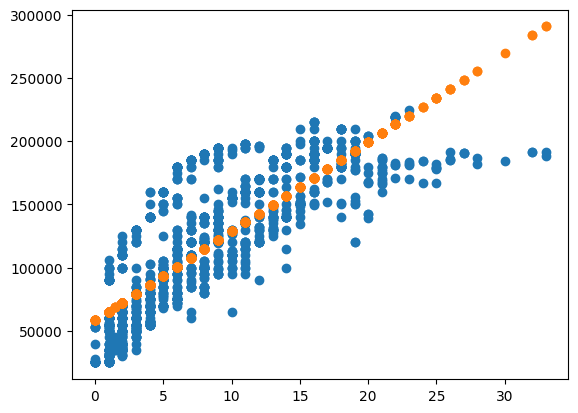

In [17]:
plt.scatter(X_test, y_test) # type: ignore[call-arg]
plt.scatter(X_test, y_pred) # type: ignore[call-arg]

## Conclusion

### About the model

The model decided the best parameters to be:
- $\beta_0=57,507.76$
- $\beta_1=7,133.48$

meaning the best fit line is:
$$Y=57,507.76 + 7,133.48x$$

Key insights we get from this formula is:
- If one has zero years of experience (x=0), then their expected salary is $58K.
- A 1 year of experience increase is expected to have a $7K salary gain.

The Mean Absolute Error is *25,390.97* meaning that the overall prediction was off to the real-data by, on average, *$25K*. Even though this might be the best we can do with simple linear regression, when interpreted in real-life, this offset is a big issue/concern for someone who may be using this model to have some insight about, for example, the job market.

Note that these values we have here change every time you change *perm* and extract the features on top of that because change in perm results in extracting another randomized datasets.

### Why is standardization not necessary?


A **closed-form solution** means the parameters for a model can be directly computed using prepared formulas. Linear Regression (simple or multi) has a closed-form solution $\theta=(X^TX)^{-1}X^Ty$ which works regardless of feature scales. So standardization is not required for Linear Regression.

However, much more complex models like Logistic Regression and Neural Networks have no closed-form solutions (parameters can't be isolated using basic algebra). Their parameters are solved by a method we call **iterative optimization** (basically by many trial and error steps). One optimization algorithm is the Gradient Descent.

**Gradient Descent** can converge slowly or inefficiently when features have very different scales. This is where standardization steps up; it fixes the extreme scale problem by bringing all features to roughly the same scale.

Though, it is important to remember that Linear Regression is often solved using Gradient Descent too. In practice, the Normal Equation becomes computationally expensive because inverting a massive matrix takes a lot of processing power. In those cases, we switch to Gradient Descent even for Linear Regression; and at that point, standardization becomes mandatory again.

### What is k-fold validation?

K-fold validation is a method used to ensure our model's performance is stable and reliable.

If we split our data into just one pair of training and testing sets, the performance (accuracy) we get is not fully reliable. It might score 91% accuracy, but that could simply be luck; the testing set may have happened to be very suitable (easy) for a high score, or the model may have overfitted.

To ensure everything is safe and under control, we split the entire dataset into **k** sets, combine **k - 1** sets into one training set, and use it to predict the remaining bucket. We measure and note the accuracy, then set up another train-test combination. We repeat this cycle until each bucket has served once as the testing set. Finally, we examine the relationship among all the measured accuracies.

- If the accuracy values vary greatly---showing high variance (standard deviation)---for example, ranging from 0.2 to 0.9, then it is clear that something is wrong, either with the model or with the features (which may require better data preparation).

- If the accuracy values have low variation and a high (expected) average accuracy, then we are good to go with the model. In that case, we use the entire dataset as one training set to train the model and have our wining parameters.

- Low variation with low accuracy suggests that other methods should be used to train the model, because this one is simply not good enough.

## Next Steps

1. Add k-fold cross-validation
2. Extend to multiple linear regression